## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [4]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

data_dir = '/project/paris/inverse_modelling/'

model_filenames = {
'rhime':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized',
'rhime_allobs':'RHIME_NAME_EUROPE_EDGAR_all_obs_rhime_baseline_optimized',
'rhime_intemobs':'RHIME_NAME_EUROPE_EDGAR_intem_obs_rhime_baseline_optimized',
'rhime_intemobsbl':'RHIME_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_fixed',
'rhime_intembf':'RHIME_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_fixed_intem_bf',
'rhime_flat':'RHIME_NAME_EUROPE_FLAT_rhime_obs_rhime_baseline_optimized',
'rhime_flat_allobs':'RHIME_NAME_EUROPE_FLAT_all_obs_rhime_baseline_optimized',
'rhime_flat_allobs_new':'RHIME_NAME_EUROPE_FLAT_all_obs_rhime_baseline_optimized_new',
'rhime_truncated':'RHIME_NAME_EUROPE_EDGAR_std_truncatednormal',

'elris':'ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized',
'elris_intemobs':'ELRIS_NAME_EUROPE_EDGAR_intem_obs_elris_baseline_optimized',
'elris_intemobsbl':'ELRIS_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_fixed',
'elris_intembl':'ELRIS_NAME_EUROPE_EDGAR_elris_obs_intem_baseline_fixed',
'elris_flat':'ELRIS_NAME_EUROPE_FLAT_elris_obs_elris_baseline_optimized',

'intem':'InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimised',
'intem_allobs':'InTEM_NAME_EUROPE_EDGAR_all_obs_intem_baseline_optimised',
'intem_flat':'InTEM_NAME_EUROPE_FLAT_intem_obs_intem_baseline_optimized',
'intem_flat_allobs':'InTEM_NAME_EUROPE_FLAT_all_obs_intem_baseline_optimized'}


model_labels = {
'rhime':'RHIME',
'rhime_allobs':'RHIME all obs',
'rhime_intemobs':'RHIME intem obs',
'rhime_intemobsbl':'RHIME intem obs/baseline',
'rhime_intembf':'RHIME intem obs/baseline/bf',
'rhime_flat':'RHIME flat',
'rhime_flat_allobs':'RHIME flat all obs',
'rhime_flat_allobs_new':'RHIME flat all obs NEW',
'rhime_truncated':'RHIME truncated',

'elris':'ELRIS',
'elris_intemobs':'ELRIS intem obs',
'elris_intemobsbl':'ELRIS intem obs/baseline',
'elris_intembl':'ELRIS intem baseline',
'elris_flat':'ELRIS flat',

'intem':'InTEM',
'intem_allobs':'InTEM all obs',
'intem_flat':'InTEM flat',
'intem_flat_allobs':'InTEM flat all obs'}

model_colors = {
'rhime':['green','lightgreen'],
'rhime_allobs':['blue','lightblue'],
'rhime_intemobs':['blue','lightblue'],
'rhime_intemobsbl':['blue','lightblue'],
'rhime_intembf':['blue','lightblue'],
'rhime_flat':['blue','lightblue'],
'rhime_flat_allobs':['blue','lightblue'],
'rhime_flat_allobs_new':['gold','khaki'],
'rhime_truncated':['gold','khaki'],

'elris':['purple','lightpurple'],
'elris_intemobs':['purple','mediumpurple'],
'elris_intemobsbl':['purple','mediumpurple'],
'elris_intembl':['purple','mediumpurple'],
'elris_flat':['purple','mediumpurple'],

'intem':['red','lightred'],
'intem_allobs':['cyan','lightcyan'],
'intem_flat':['cyan','lightcyan'],
'intem_flat_allobs':['cyan','lightcyan']}

experiments = {
    '1':['rhime','intem','elris'],
    '2':['rhime','rhime_allobs','intem_allobs','elris'],
    '3':['rhime','rhime_intemobs','intem','elris_intemobs'],
    '4':['rhime','rhime_intemobsbl','intem','elris_intemobsbl'],
    '5':['rhime','intem','rhime_intembf'],
    '6':['rhime','rhime_flat','intem','intem_flat'],
    '7':['rhime_flat','rhime_flat_allobs','intem_flat','intem_flat_allobs']}

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [5]:
###################################
### edit variables in this block
species = 'pfc218'
models = experiments['1']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2023-01-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]


Attempting to read data from rhime
Reading data from: /project/paris/inverse_modelling/RHIME/pfc218/RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_pfc218_yearly.nc
Done!

Attempting to read data from intem
Reading data from: /project/paris/inverse_modelling/InTEM/pfc218/InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimised_pfc218_yearly.nc
Done!

Attempting to read data from elris
Reading data from: /project/paris/inverse_modelling/ELRIS/pfc218/ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_PFC_218_yearly.nc
Done!

Masking data from rhime
Scaling rhime units by 1000000.0

Masking data from intem
Scaling intem units by 1000000.0

Masking data from elris
Scaling elris units by 1000000.0
Scaling covariance units in elris by 1000000000000.0


#### Timeseries of country fluxes:

No inventory data available for BENELUX. Considering sum of individual countries: BEL-LUX-NLD
BENELUX emissions are not present in elris. Considering covariance matrix and sum of individual countries: BEL-LUX-NLD.
No inventory data available for NW_EU2. Considering sum of individual countries: BEL-DEU-FRA-GBR-IRL-LUX-NLD
NW_EU2 emissions are not present in elris. Considering covariance matrix and sum of individual countries: BEL-DEU-FRA-GBR-IRL-LUX-NLD.
NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


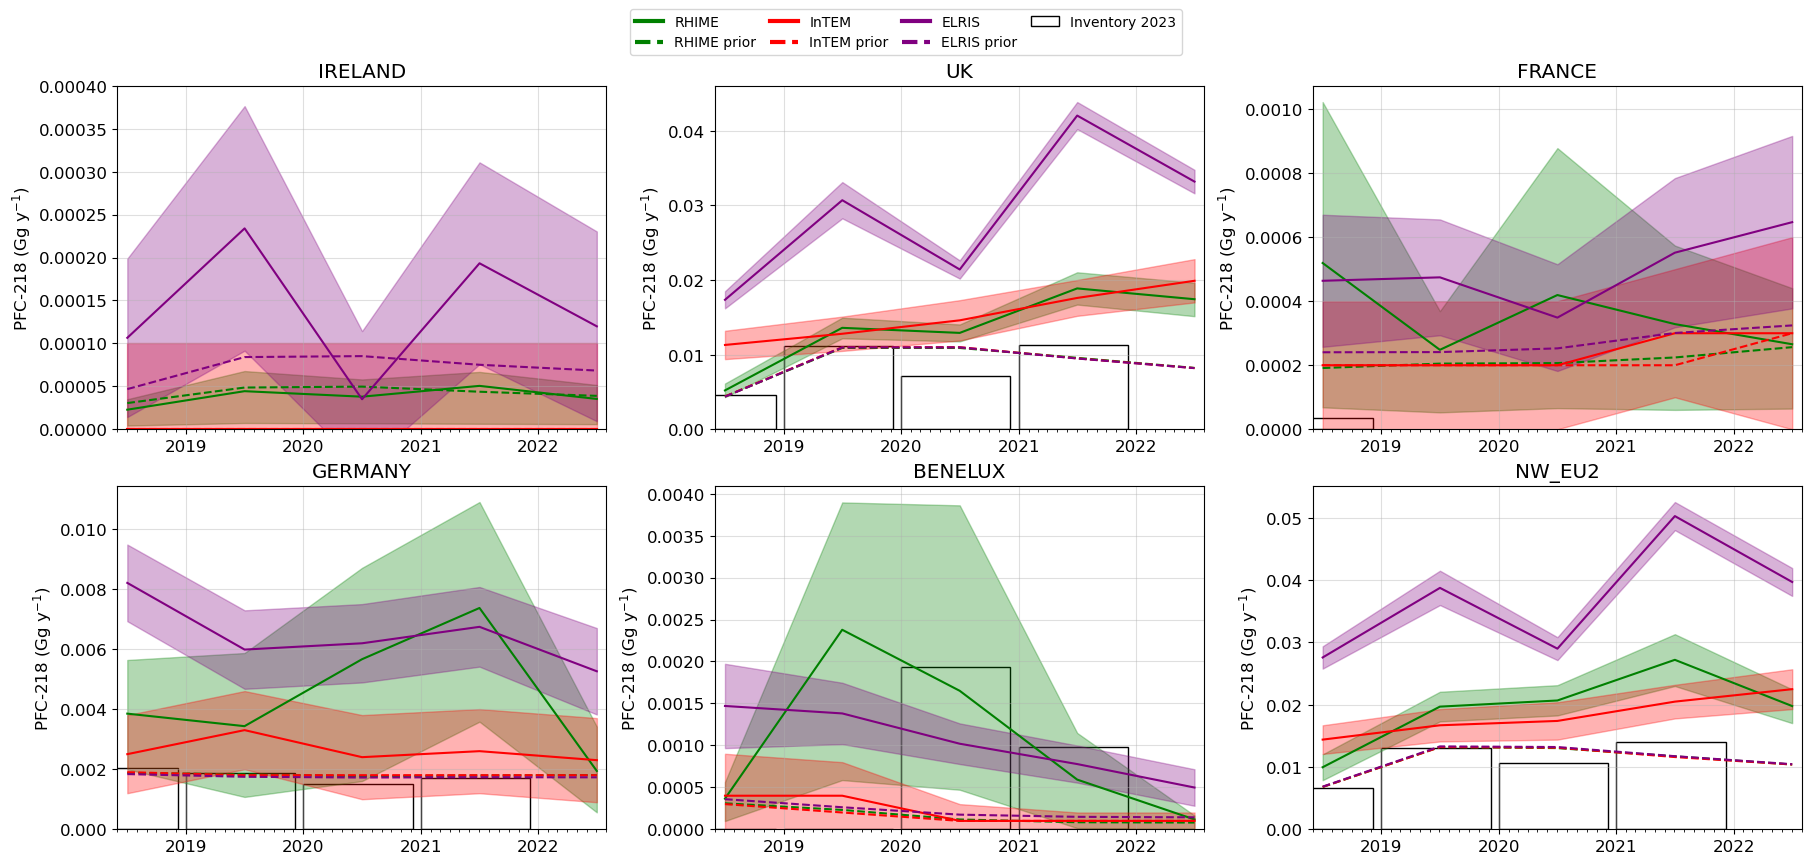

In [6]:
###################################
### edit variables in this block
plot_regions = ['IRELAND','UK','FRANCE','GERMANY','BENELUX','NW_EU2'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = True #If True, combined results, averaged from all models
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined)

Save plot here:

In [ ]:
#output_path = '/home/h02/aramsden/results/PARIS_results_comparison/fixed_baseline/InTEM_Feb2024_E-D_fixed_baseline_comparison_countryfluxes.png'

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'hfc143a' 
site = 'MHD'
models = ['intem_inner','intem_outer']#'rhime',]
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [7]:
###################################
### edit variables in this block
species = 'hfc125'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = ['intem','elris']#,'rhime','elris_name']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]


Attempting to read data from intem
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/InTEM/hfc125/InTEM_NAME_EUROPE_EDGAR_all_obs_intem_baseline_optimized_hfc125_yearly.nc
Done!

Attempting to read data from elris
Reading data from: /project/InTEM_GHG/inversion/PARIS_results_sharing/ELRIS/hfc125/ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized_HFC_125_yearly.nc
Done!

Masking data from intem
Scaling intem units by 1000000.0

Masking data from elris
Scaling elris units by 1000000.0
Scaling covariance units in elris by 1000000000000.0


##### Prior and posterior fluxes for all models:

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


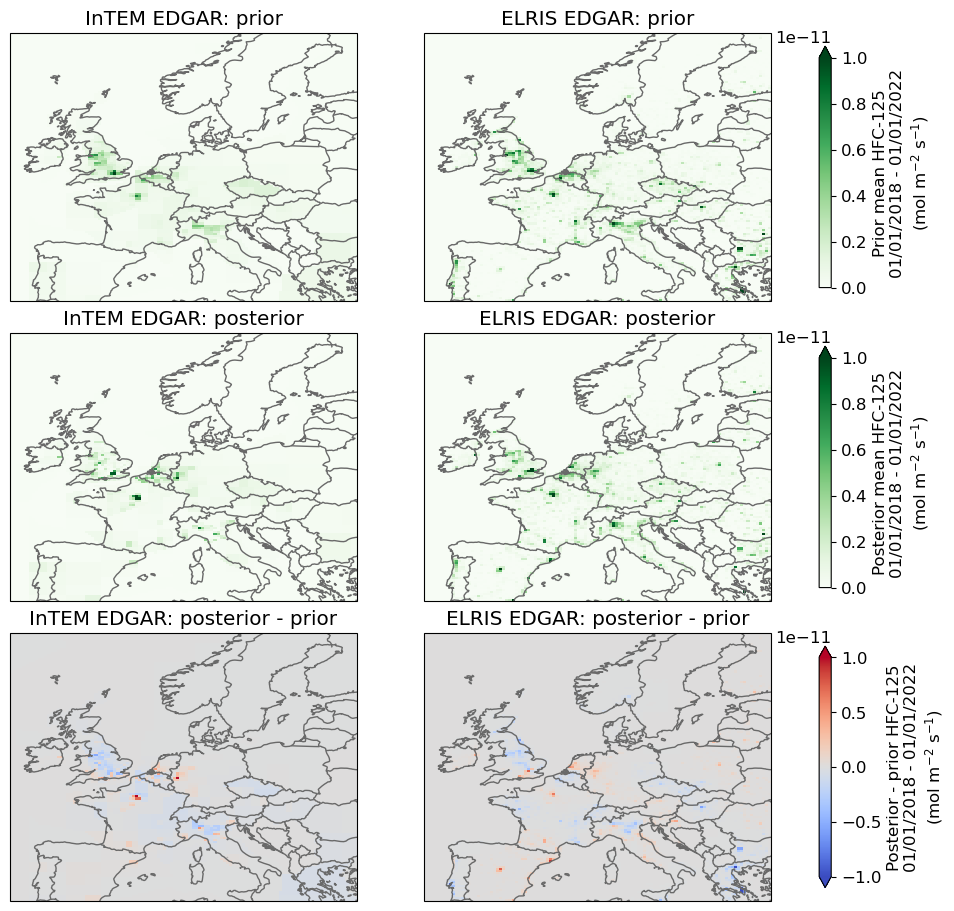

In [13]:
###################################
### edit variables in this block
plot_area = 'CWEU' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'viridis'   #Greens
cmap_diff = 'coolwarm'
c_border = 'floralwhite'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers)

##### Directly compare posterior fluxes from two models:

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


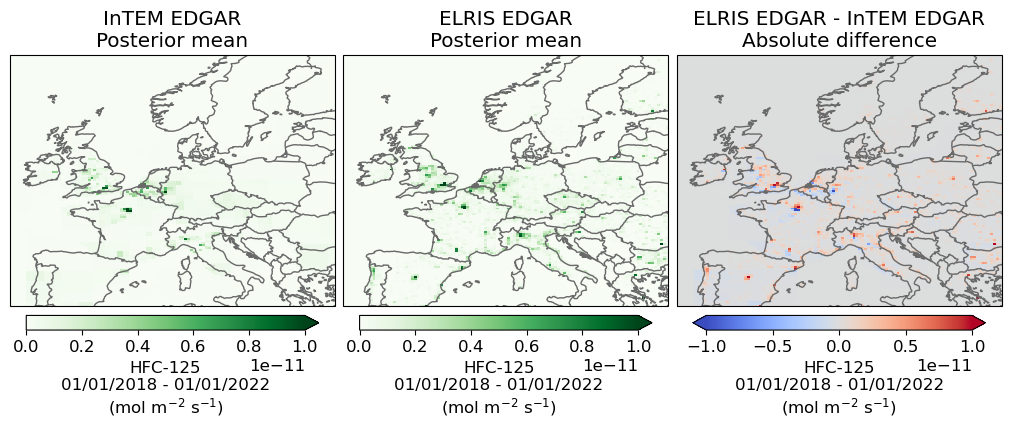

In [15]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers)

##### Plot prior, posterior or difference fluxes per time interval:

In [ ]:
###################################
### edit variables in this block
plot_area = 'CWEU'   #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'coolwarm'    #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'dimgrey' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
chop_by = 'year'     #time unit of the averaging period (options for 'year' and 'month')
                     #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 2               #number of time steps (in chop_by units) to use in the averaging
var = 'posterior_prior_diff'  #variable to be plotted.
                              #options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff'
plot_site_locations = True #If True, adds markers to plots at locations of obs sites
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,model_labels,end_date,
                                            cmap=cmap,c_border=c_border,
                                            var=var,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')